# Week 4 Data Exploration Challenge
## Welltory COVID-19 and Wearables Open Data Research Dataset

### Data Context

The Welltory COVID-19 and Wearables dataset contains health and wearable data collected during the COVID-19 pandemic. It includes information such as heart rate variability (HRV), heart rate, sleep, blood pressure, wearable measurements, surveys, weather, and participant information.

The purpose of this exploration is to understand the structure and quality of this real-world dataset, identify patterns and relationships between variables, address data quality issues, and create useful features for further analysis.

In [1]:
!git clone https://github.com/Welltory/hrv-covid19.git

Cloning into 'hrv-covid19'...
remote: Enumerating objects: 198, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 198 (delta 5), reused 4 (delta 1), pack-reused 186 (from 1)
Receiving objects: 100% (198/198), 4.57 MiB | 6.63 MiB/s, done.
Resolving deltas: 100% (128/128), done.


In [2]:
!ls hrv-covid19/data

blood_pressure.csv    participants.csv	      surveys.csv
heart_rate.csv	      scales_description.csv  wearables.csv
hrv_measurements.csv  sleep.csv		      weather.csv


## Import Libraries

The following Python libraries are used to load, explore, clean, and visualize the data.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load and Preview the Data

I will primarily explore the HRV measurements dataset because it contains physiological measurements that can be used to examine heart rate variability and relationships between health-related variables.

In [4]:
df = pd.read_csv("hrv-covid19/data/hrv_measurements.csv")

df.head()

,user_code,rr_code,measurement_datetime,time_of_day,bpm,meanrr,mxdmn,sdnn,rmssd,pnn50,...,lf,hf,vlf,lfhf,total_power,how_feel,how_mood,how_sleep,tags,rr_data
0,007b8190cf,10489a6aea,2020-04-21 21:23:08,morning,75,795.90,0.12,45.802,54.174,15.15,...,508.0,1076.0,267.0,0.472,1851.0,0,-1,NaN,COVID-19; Workout; Sex; Hobby; Studying; Sleep...,"819,1008,831,847,785,778,866,839,801,793,846,8..."
1,007b8190cf,9610d4d4dc,2020-04-26 11:19:25,morning,70,858.00,0.11,32.889,33.022,16.16,...,409.0,310.0,176.0,1.319,895.0,0,0,0.0,NaN,"888,775,811,883,890,894,894,899,893,889,890,83..."
2,013f6d3e5b,f3de056155,2020-05-15 04:14:21,night,83,724.10,0.17,54.811,65.987,17.17,...,432.0,881.0,194.0,0.490,1507.0,-1,-2,NaN,COVID-19; Fast/Diet; Hungry; Tired; Fever; I c...,"694,832,642,801,751,716,737,742,773,760,701,73..."
3,013f6d3e5b,b04489e32f,2020-05-19 03:06:02,night,75,802.64,0.20,72.223,70.039,22.22,...,814.0,1487.0,1719.0,0.547,4020.0,0,0,NaN,NaN,"821,817,771,805,833,788,747,724,792,825,775,75..."
4,01bad5a519,ac52c706c6,2019-12-31 09:07:43,morning,78,768.07,0.10,29.650,21.196,4.04,...,489.0,128.0,96.0,3.820,713.0,0,0,0.0,NaN,"741,740,734,737,740,731,751,747,745,728,747,76..."


In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 3245
Number of columns: 22


In [6]:
df.columns.tolist()

['user_code',
 'rr_code',
 'measurement_datetime',
 'time_of_day',
 'bpm',
 'meanrr',
 'mxdmn',
 'sdnn',
 'rmssd',
 'pnn50',
 'mode',
 'amo',
 'lf',
 'hf',
 'vlf',
 'lfhf',
 'total_power',
 'how_feel',
 'how_mood',
 'how_sleep',
 'tags',
 'rr_data']

## Understanding the Features

The HRV dataset contains 3,245 measurements and 22 features. Each row represents an HRV measurement rather than a unique participant, meaning that the same participant may have multiple measurements.

The main features include:

- **user_code:** Anonymous identifier for each participant
- **rr_code:** Identifier for the HRV measurement
- **measurement_datetime:** Date and time when the measurement was taken
- **time_of_day:** Time-of-day category for the measurement
- **bpm:** Heart rate in beats per minute
- **meanrr:** Average time between consecutive heartbeats
- **mxdmn:** Difference between the longest and shortest RR intervals
- **sdnn:** Standard deviation of RR intervals, representing overall heart rate variability
- **rmssd:** Measure of short-term heart rate variability
- **pnn50:** Percentage of consecutive RR intervals that differ by more than 50 ms
- **mode:** Most common RR interval
- **amo:** Percentage of RR intervals corresponding to the mode
- **lf:** Low-frequency HRV power
- **hf:** High-frequency HRV power
- **vlf:** Very-low-frequency HRV power
- **lfhf:** Ratio of low-frequency to high-frequency power
- **total_power:** Total HRV spectral power
- **how_feel:** Self-reported physical well-being
- **how_mood:** Self-reported mood
- **how_sleep:** Self-reported sleep quality
- **tags:** User-provided contextual tags associated with the measurement
- **rr_data:** Raw RR interval data used to calculate HRV measurements

## Data Context and Sampling

The data were collected as part of Welltory's COVID-19 research using the Welltory health application and connected measurement devices. The dataset contains repeated physiological measurements from participants rather than one observation per person.

The sample should not be considered a random sample of the general population. Participants voluntarily participated in the research and needed access to the Welltory app and compatible technology. This could introduce selection bias because people who use health-tracking technology may differ from the general population.

Participants may also have different numbers of measurements. Therefore, participants who recorded their HRV more frequently may contribute more observations to the dataset than other participants.

In [7]:
print("Number of HRV measurements:", len(df))
print("Number of unique participants:", df["user_code"].nunique())

Number of HRV measurements: 3245
Number of unique participants: 185


## Data Structure

Next, I examined the data types and non-null values for each feature. This helps identify variables that may require cleaning or transformation before analysis.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3245 entries, 0 to 3244
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_code             3245 non-null   object 
 1   rr_code               3245 non-null   object 
 2   measurement_datetime  3245 non-null   object 
 3   time_of_day           3245 non-null   object 
 4   bpm                   3245 non-null   int64  
 5   meanrr                3245 non-null   float64
 6   mxdmn                 3245 non-null   float64
 7   sdnn                  3245 non-null   float64
 8   rmssd                 3245 non-null   float64
 9   pnn50                 3245 non-null   float64
 10  mode                  3245 non-null   float64
 11  amo                   3245 non-null   float64
 12  lf                    3245 non-null   float64
 13  hf                    3245 non-null   float64
 14  vlf                   3245 non-null   float64
 15  lfhf                 

## Descriptive Statistics

I examined descriptive statistics for the numerical features to understand their typical values, variability, ranges, and potential extreme values. Comparing values such as the mean, median, minimum, and maximum can also help identify skewed distributions and possible outliers.

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
bpm,3245.0,73.257935,12.201088,44.000,65.000,72.000,81.000,125.000
meanrr,3245.0,839.600366,137.420367,477.730,742.490,829.100,925.933,1346.740
mxdmn,3245.0,0.184635,0.107456,0.030,0.110,0.160,0.220,0.790
sdnn,3245.0,52.489218,29.369506,9.515,32.585,46.919,64.406,206.631
rmssd,3245.0,52.814196,39.353213,6.340,28.985,42.869,62.485,310.800
pnn50,3245.0,20.615609,18.588156,0.000,6.060,16.160,29.290,91.920
mode,3245.0,0.837465,0.144769,0.475,0.725,0.825,0.925,1.325
amo,3245.0,46.788290,16.418873,12.000,35.000,45.000,57.000,98.000
lf,3245.0,927.038213,1455.424089,2.000,151.000,423.000,1059.000,15522.000
hf,3245.0,1125.041294,2490.540413,4.000,158.000,380.000,993.000,33490.000


## Missing Values

I examined missing values to assess data completeness and determine whether missing data required cleaning. I did not automatically remove rows with missing values because doing so could unnecessarily reduce the dataset and potentially introduce bias.

In [10]:
missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percent": (df.isnull().mean() * 100).round(2)
})

missing.sort_values("Missing Percent", ascending=False)

,Missing Count,Missing Percent
how_sleep,1779,54.82
tags,1044,32.17
measurement_datetime,0,0.00
time_of_day,0,0.00
user_code,0,0.00
rr_code,0,0.00
meanrr,0,0.00
bpm,0,0.00
mxdmn,0,0.00
sdnn,0,0.00


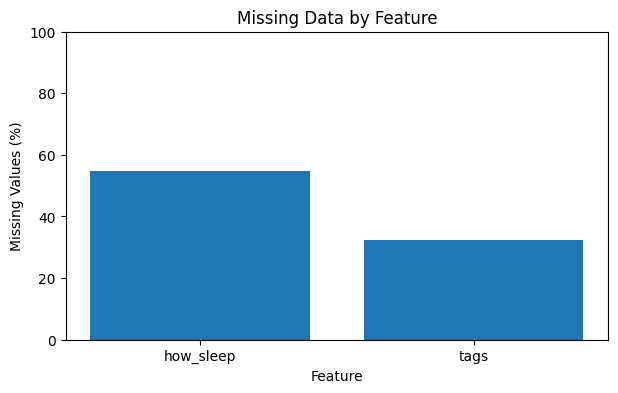

In [11]:
missing_plot = missing[missing["Missing Percent"] > 0]

plt.figure(figsize=(7, 4))
plt.bar(missing_plot.index, missing_plot["Missing Percent"])
plt.ylabel("Missing Values (%)")
plt.xlabel("Feature")
plt.title("Missing Data by Feature")
plt.ylim(0, 100)
plt.show()

### Missing Value Strategy

Only two features contain missing values. `how_sleep` is missing 54.82% of its observations, while `tags` is missing 32.17%.

I chose not to remove all rows containing missing values because doing so would eliminate a large portion of otherwise useful HRV measurements. I also chose not to impute `how_sleep` because more than half of the values are missing, and filling these values could create artificial self-reported sleep information. Missing `tags` values were also retained because tags provide optional contextual information and are not required for the primary HRV analysis.

Therefore, the missing values will remain in the dataset and will be excluded only from analyses that specifically require those variables.

## Duplicate Observations

I checked for exact duplicate rows because duplicates could cause certain measurements to be counted more than once and potentially bias the analysis.

In [12]:
duplicate_count = df.duplicated().sum()

print("Number of exact duplicate rows:", duplicate_count)

Number of exact duplicate rows: 0


### Duplicate Handling Strategy

The dataset contained 0 exact duplicate rows. Therefore, no rows were removed for duplication. Multiple measurements from the same participant were not considered duplicates because participants can legitimately record HRV measurements multiple times.

## Outlier Assessment

I examined potential outliers in heart rate (BPM) using a boxplot and the interquartile range (IQR) method. Outliers are important to investigate in physiological data because extreme values may represent either measurement errors or legitimate biological variation.

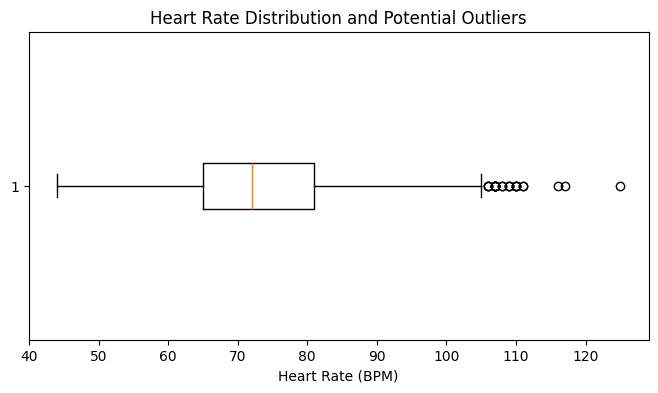

In [13]:
plt.figure(figsize=(8, 4))
plt.boxplot(df["bpm"].dropna(), vert=False)

plt.xlabel("Heart Rate (BPM)")
plt.title("Heart Rate Distribution and Potential Outliers")
plt.show()

In [14]:
Q1 = df["bpm"].quantile(0.25)
Q3 = df["bpm"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

bpm_outliers = df[
    (df["bpm"] < lower_bound) |
    (df["bpm"] > upper_bound)
]

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Number of potential BPM outliers:", len(bpm_outliers))

Lower bound: 41.0
Upper bound: 105.0
Number of potential BPM outliers: 25


### Outlier Handling Strategy

Using the IQR method, values below 41 BPM or above 105 BPM were identified as potential outliers. There were 25 potential BPM outliers.

I chose not to remove these observations. The observed BPM values ranged from 44 to 125 BPM, so the identified outliers were high heart-rate measurements rather than obviously impossible values. Because this is physiological data, an extreme value may represent real biological variation rather than a data error. Removing these observations solely because they are statistical outliers could remove meaningful health information.

## Visual Exploration and Variable Relationships

I used visualizations to better understand the distributions of important physiological variables and explore relationships between HRV measurements.

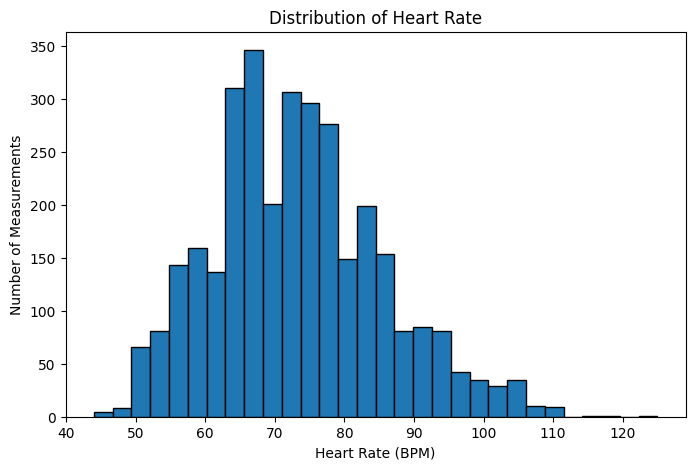

In [15]:
plt.figure(figsize=(8, 5))
plt.hist(df["bpm"], bins=30, edgecolor="black")

plt.xlabel("Heart Rate (BPM)")
plt.ylabel("Number of Measurements")
plt.title("Distribution of Heart Rate")
plt.show()

The heart rate distribution is centered around the low 70s, which is consistent with the median BPM of 72. Most measurements are concentrated within a relatively narrow range, while fewer measurements occur at the higher end of the distribution.

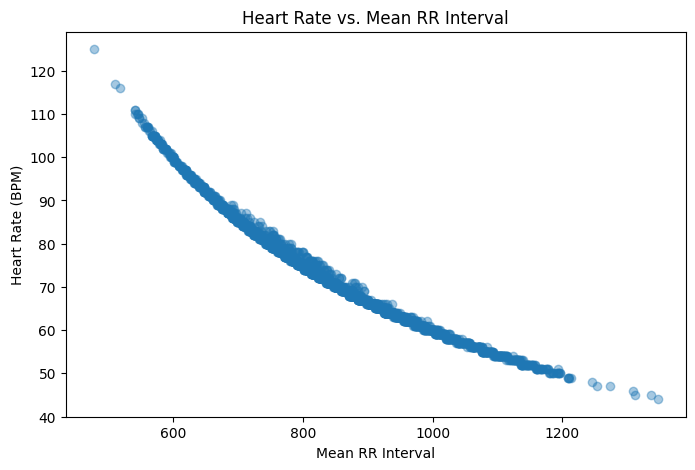

In [16]:
plt.figure(figsize=(8, 5))

plt.scatter(df["meanrr"], df["bpm"], alpha=0.4)

plt.xlabel("Mean RR Interval")
plt.ylabel("Heart Rate (BPM)")
plt.title("Heart Rate vs. Mean RR Interval")

plt.show()

The scatterplot shows a strong inverse relationship between mean RR interval and heart rate. As the average time between heartbeats increases, heart rate decreases. This relationship is physiologically expected because a faster heart rate means there is less time between consecutive heartbeats.

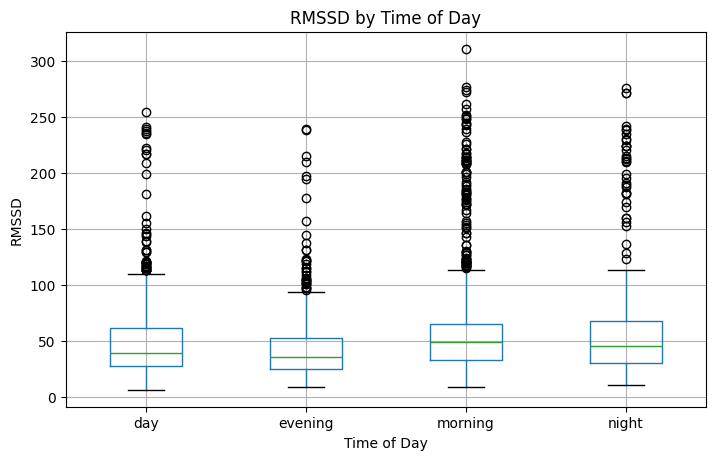

In [17]:
df.boxplot(column="rmssd", by="time_of_day", figsize=(8, 5))

plt.title("RMSSD by Time of Day")
plt.suptitle("")
plt.xlabel("Time of Day")
plt.ylabel("RMSSD")
plt.show()

The RMSSD distributions vary somewhat by time of day. Morning measurements have the highest median RMSSD, while evening measurements have the lowest median. Day and night measurements fall between these groups.

All four time-of-day categories also contain many high-value outliers, indicating that RMSSD is right-skewed and can vary substantially between measurements. These differences suggest that time of day may be relevant when analyzing HRV.

## Data Transformation

The `measurement_datetime` feature was originally stored as an object rather than a datetime variable. I converted it to a datetime format so that the date and time components can be analyzed appropriately. This allows temporal features such as the measurement hour to be extracted from the original timestamp.

In [18]:
df["measurement_datetime"] = pd.to_datetime(
    df["measurement_datetime"],
    errors="coerce"
)

df["measurement_hour"] = df["measurement_datetime"].dt.hour

df[["measurement_datetime", "measurement_hour"]].head()

,measurement_datetime,measurement_hour
0,2020-04-21 21:23:08,21
1,2020-04-26 11:19:25,11
2,2020-05-15 04:14:21,4
3,2020-05-19 03:06:02,3
4,2019-12-31 09:07:43,9


## Feature Engineering

To create a feature that is more relevant to the COVID-19 research context, I examined participant information together with the HRV measurement dates.

In [19]:
participants = pd.read_csv("hrv-covid19/data/participants.csv")

participants.head()

,user_code,gender,age_range,city,country,height,weight,symptoms_onset
0,007b8190cf,m,25-34,Mandalay,Myanmar,170.18,96.162,NaN
1,013f6d3e5b,f,18-24,São Paulo,Brazil,174.00,77.300,5/15/2020
2,01bad5a519,m,45-54,St Petersburg,Russia,178.00,92.000,4/5/2020
3,0210b20eea,f,25-34,Sochi,Russia,169.00,60.000,5/6/2020
4,024719e7da,f,45-54,St Petersburg,Russia,158.00,68.500,5/27/2020


In [20]:
participants.columns.tolist()

['user_code',
 'gender',
 'age_range',
 'city',
 'country',
 'height',
 'weight',
 'symptoms_onset']

In [21]:
participants["symptoms_onset"] = pd.to_datetime(
    participants["symptoms_onset"],
    errors="coerce"
)

participants[["user_code", "symptoms_onset"]].head()

,user_code,symptoms_onset
0,007b8190cf,NaT
1,013f6d3e5b,2020-05-15
2,01bad5a519,2020-04-05
3,0210b20eea,2020-05-06
4,024719e7da,2020-05-27


In [22]:
df = df.merge(
    participants[["user_code", "symptoms_onset"]],
    on="user_code",
    how="left"
)

df[["user_code", "measurement_datetime", "symptoms_onset"]].head()

,user_code,measurement_datetime,symptoms_onset
0,007b8190cf,2020-04-21 21:23:08,NaT
1,007b8190cf,2020-04-26 11:19:25,NaT
2,013f6d3e5b,2020-05-15 04:14:21,2020-05-15
3,013f6d3e5b,2020-05-19 03:06:02,2020-05-15
4,01bad5a519,2019-12-31 09:07:43,2020-04-05


In [23]:
df["days_since_symptom_onset"] = (
    df["measurement_datetime"].dt.normalize()
    - df["symptoms_onset"].dt.normalize()
).dt.days

df[
    ["measurement_datetime", "symptoms_onset", "days_since_symptom_onset"]
].head(10)

,measurement_datetime,symptoms_onset,days_since_symptom_onset
0,2020-04-21 21:23:08,NaT,NaN
1,2020-04-26 11:19:25,NaT,NaN
2,2020-05-15 04:14:21,2020-05-15,0.0
3,2020-05-19 03:06:02,2020-05-15,4.0
4,2019-12-31 09:07:43,2020-04-05,-96.0
5,2020-01-11 14:52:39,2020-04-05,-85.0
6,2020-01-30 17:55:54,2020-04-05,-66.0
7,2020-04-02 12:07:09,2020-04-05,-3.0
8,2020-04-12 15:00:58,2020-04-05,7.0
9,2020-04-13 19:17:50,2020-04-05,8.0


### New Feature: Days Since Symptom Onset

I created a new feature called `days_since_symptom_onset`, which represents the number of days between a participant's reported COVID-19 symptom onset and each HRV measurement.

This feature is useful because calendar dates alone do not indicate where a participant was in the course of illness. Converting the measurements into time relative to symptom onset makes it easier to compare participants and potentially examine physiological changes associated with COVID-19 progression and recovery.

Negative values represent measurements taken before reported symptom onset, 0 represents the symptom-onset date, and positive values represent measurements taken after symptom onset. Missing values were retained when a participant did not have a recorded symptom-onset date rather than estimating an unknown date.

## Data Quality Assessment

### Data Profiling
I profiled the dataset by examining its dimensions, column names, data types, descriptive statistics, missing values, duplicate observations, distributions, and potential outliers. This helped identify data quality issues before further analysis.

### Data Completeness
Most HRV features were complete. However, `how_sleep` was missing 54.82% of its values and `tags` was missing 32.17%. I retained these missing values rather than deleting large amounts of otherwise useful HRV data or creating artificial values through imputation.

### Data Accuracy
Physiological measurements may be affected by wearable devices, sensors, measurement conditions, or user behavior. Potential BPM outliers were therefore investigated rather than automatically removed. The observed heart rates ranged from 44 to 125 BPM, so the extreme values were not clearly impossible measurements.

### Data Consistency
I examined data types and variable formats for consistency. The `measurement_datetime` variable was originally stored as an object and was converted to a datetime format to allow appropriate temporal analysis.

### Data Integrity
The dataset contained no exact duplicate rows. Multiple measurements from the same participant were retained because repeated HRV measurements are legitimate observations rather than duplicates. Participant information was linked to HRV measurements using the anonymous `user_code` identifier.

### Data Lineage and Provenance
The data come from Welltory's COVID-19 and Wearables Open Data Research dataset. The dataset contains information collected through the Welltory platform, including physiological measurements and participant-reported information. Understanding the source of the data is important because measurements collected from devices and self-reported information can have different sources of error and uncertainty.

## Conclusion

This exploration demonstrated several challenges associated with real-world health and wearable data, including missing information, repeated participant measurements, potential physiological outliers, and variables requiring transformation.

Rather than automatically deleting incomplete or extreme observations, cleaning decisions were based on the context and meaning of the data. The analysis also identified relationships among physiological variables and differences in HRV across time of day.

Finally, I created `days_since_symptom_onset` to represent the timing of each HRV measurement relative to COVID-19 symptom onset. This feature could be useful in future analyses examining physiological changes during disease progression and recovery.